### Código utilizando data sólo de Medellín

In [ ]:
# se agrega este nuevo filtro
## df = df[df['Ciudad'].str.upper() == 'MEDELLIN']

Dimensiones originales: (15568, 50)
Dimensiones solo Medellín: (2487, 50)
Dimensiones después limpieza: (1913, 14)
0:	learn: 3672356.5048031	total: 158ms	remaining: 2m 37s
100:	learn: 1269774.6000782	total: 3.3s	remaining: 29.4s
200:	learn: 964617.7031928	total: 6.61s	remaining: 26.3s
300:	learn: 778412.1630476	total: 10.2s	remaining: 23.8s
400:	learn: 649085.4785531	total: 13.9s	remaining: 20.8s
500:	learn: 551476.1712138	total: 18.5s	remaining: 18.4s
600:	learn: 485718.0485382	total: 22.8s	remaining: 15.1s
700:	learn: 434742.4034231	total: 26.8s	remaining: 11.4s
800:	learn: 395557.9904287	total: 31.2s	remaining: 7.76s
900:	learn: 366153.4761286	total: 34.9s	remaining: 3.83s
999:	learn: 339151.4561247	total: 38.7s	remaining: 0us

RESULTADOS MODELO
MAE: 420328.92
RMSE: 581974.65
R²: 0.9746
MAPE: 5.28 %

Cross Validation R²:
[0.9764338899780393, 0.958719263431826, 0.9742184036352569, 0.9625488418143704, 0.9714484412819174]
Promedio: 0.968673768028282

IMPORTANCIA VARIABLES
             

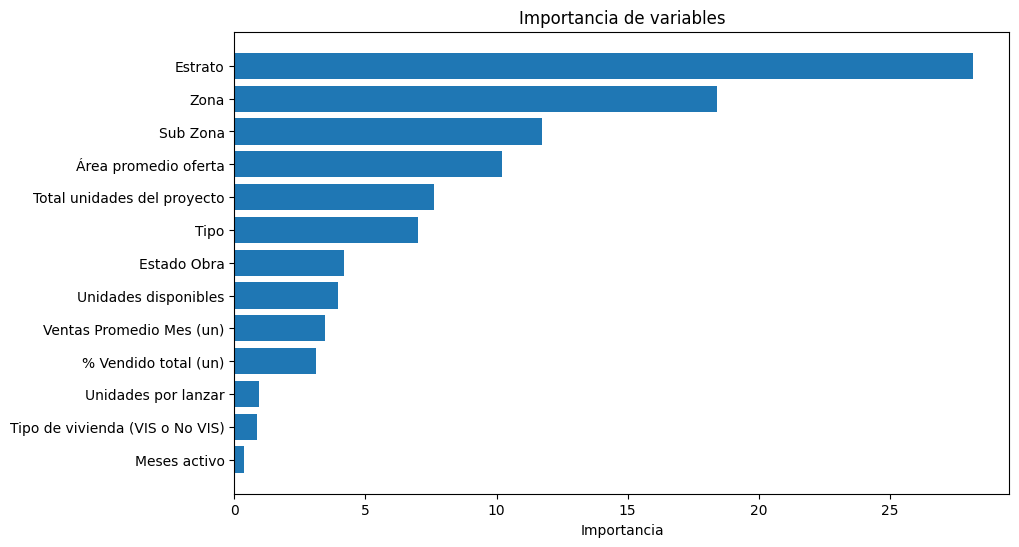


PREDICCIÓN NUEVO INMUEBLE
Precio estimado m²: 7965909.0


In [1]:
# ============================================================
# 1. LIBRERÍAS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import KFold
from catboost import CatBoostRegressor


# ============================================================
# 2. CARGAR EXCEL
# ============================================================

ruta = r"C:\Users\Usuario\Desktop\Trabajo Final Aprendizaje Maquinas\Base competitividad-Completa.xlsx"

df = pd.read_excel(ruta)

print("Dimensiones originales:", df.shape)


# ============================================================
# 3. FILTRAR SOLO MEDELLÍN
# ============================================================

df['Ciudad'] = df['Ciudad'].astype(str).str.strip()

df = df[
    df['Ciudad'].str.upper() == 'MEDELLIN'
]

print("Dimensiones solo Medellín:", df.shape)


# ============================================================
# 4. SELECCIÓN VARIABLES
# ============================================================

columnas_modelo = [
    'Zona',
    'Sub Zona',
    'Estrato',
    'Área promedio oferta',
    'Meses activo',
    'Ventas Promedio Mes (un)',
    'Total unidades del proyecto',
    'Unidades disponibles',
    'Unidades por lanzar',
    '% Vendido total (un)',
    'Tipo',
    'Tipo de vivienda (VIS o No VIS)',
    'Estado Obra',
    '$ Prom. Oferta m2'
]

df = df[columnas_modelo].copy()


# ============================================================
# 5. LIMPIEZA TARGET
# ============================================================

df['$ Prom. Oferta m2'] = pd.to_numeric(
    df['$ Prom. Oferta m2'],
    errors='coerce'
)

df = df[df['$ Prom. Oferta m2'].notnull()]

df = df[df['$ Prom. Oferta m2'] > 1000000]
df = df[df['$ Prom. Oferta m2'] < 50000000]


# ============================================================
# 6. VARIABLES NUMÉRICAS
# ============================================================

numericas = [
    'Estrato',
    'Área promedio oferta',
    'Meses activo',
    'Ventas Promedio Mes (un)',
    'Total unidades del proyecto',
    'Unidades disponibles',
    'Unidades por lanzar',
    '% Vendido total (un)'
]

for col in numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')


# ============================================================
# 7. IMPUTACIÓN
# ============================================================

for col in numericas:
    df[col] = df[col].fillna(df[col].median())

categoricas = [
    'Zona',
    'Sub Zona',
    'Tipo',
    'Tipo de vivienda (VIS o No VIS)',
    'Estado Obra'
]

for col in categoricas:
    df[col] = df[col].fillna('Desconocido')


# ============================================================
# 8. ELIMINAR OUTLIERS
# ============================================================

Q1 = df['$ Prom. Oferta m2'].quantile(0.25)
Q3 = df['$ Prom. Oferta m2'].quantile(0.75)

IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

df = df[
    (df['$ Prom. Oferta m2'] >= lim_inf) &
    (df['$ Prom. Oferta m2'] <= lim_sup)
]

print("Dimensiones después limpieza:", df.shape)


# ============================================================
# 9. DEFINIR X E Y
# ============================================================

X = df.drop(columns=['$ Prom. Oferta m2'])
y = df['$ Prom. Oferta m2']


# ============================================================
# 10. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 11. VARIABLES CATEGÓRICAS
# ============================================================

cat_features = [
    'Zona',
    'Sub Zona',
    'Tipo',
    'Tipo de vivienda (VIS o No VIS)',
    'Estado Obra'
]


# ============================================================
# 12. MODELO CATBOOST
# ============================================================

modelo = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=8,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=100
)

modelo.fit(
    X_train,
    y_train,
    cat_features=cat_features
)


# ============================================================
# 13. PREDICCIÓN TEST
# ============================================================

y_pred = modelo.predict(X_test)


# ============================================================
# 14. MÉTRICAS
# ============================================================

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("\nRESULTADOS MODELO")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 4))
print("MAPE:", round(mape, 2), "%")


# ============================================================
# 15. CROSS VALIDATION
# ============================================================

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = []

for train_idx, val_idx in kf.split(X):

    X_train_cv = X.iloc[train_idx]
    X_val_cv = X.iloc[val_idx]

    y_train_cv = y.iloc[train_idx]
    y_val_cv = y.iloc[val_idx]

    modelo_cv = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.03,
        depth=8,
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=42,
        verbose=0
    )

    modelo_cv.fit(
        X_train_cv,
        y_train_cv,
        cat_features=cat_features
    )

    pred_cv = modelo_cv.predict(X_val_cv)

    score = r2_score(y_val_cv, pred_cv)

    cv_scores.append(score)

print("\nCross Validation R²:")
print(cv_scores)
print("Promedio:", np.mean(cv_scores))


# ============================================================
# 16. IMPORTANCIA VARIABLES
# ============================================================

importancias = modelo.get_feature_importance()

imp_df = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importancias
}).sort_values(
    by='Importancia',
    ascending=False
)

print("\nIMPORTANCIA VARIABLES")
print(imp_df)


# ============================================================
# 17. GRÁFICA
# ============================================================

plt.figure(figsize=(10, 6))
plt.barh(imp_df['Variable'], imp_df['Importancia'])
plt.gca().invert_yaxis()
plt.title('Importancia de variables')
plt.xlabel('Importancia')
plt.show()


# ============================================================
# 18. PREDICCIÓN NUEVO CASO
# ============================================================

nuevo = pd.DataFrame({
    'Zona': ['El Poblado'],
    'Sub Zona': ['Castropol'],
    'Estrato': [6],
    'Área promedio oferta': [95],
    'Meses activo': [2],
    'Ventas Promedio Mes (un)': [4],
    'Total unidades del proyecto': [180],
    'Unidades disponibles': [150],
    'Unidades por lanzar': [60],
    '% Vendido total (un)': [12],
    'Tipo': ['Apartamento'],
    'Tipo de vivienda (VIS o No VIS)': ['No VIS'],
    'Estado Obra': ['Preventa']
})

pred = modelo.predict(nuevo)

print("\nPREDICCIÓN NUEVO INMUEBLE")
print("Precio estimado m²:", round(pred[0], 0))

In [2]:
nuevo = pd.DataFrame({
    'Zona': ['Sabaneta'],
    'Sub Zona': ['Aves Maria'],
    'Estrato': [4],
    'Área promedio oferta': [78],
    'Meses activo': [8],
    'Ventas Promedio Mes (un)': [9],
    'Total unidades del proyecto': [140],
    'Unidades disponibles': [28],
    'Unidades por lanzar': [0],
    '% Vendido total (un)': [80],
    'Tipo': ['Apartamento'],
    'Tipo de vivienda (VIS o No VIS)': ['No VIS'],
    'Estado Obra': ['Construcción']
})

pred = modelo.predict(nuevo)

print("\nPREDICCIÓN SABANETA")
print("Precio estimado m²:", round(pred[0], 0))


PREDICCIÓN SABANETA
Precio estimado m²: 5937512.0


In [4]:
nuevo = pd.DataFrame({
    'Zona': ['Envigado'],
    'Sub Zona': ['Las Vegas'],
    'Estrato': [5],
    'Área promedio oferta': [90],
    'Meses activo': [10],
    'Ventas Promedio Mes (un)': [12],
    'Total unidades del proyecto': [160],
    'Unidades disponibles': [35],
    'Unidades por lanzar': [0],
    '% Vendido total (un)': [78],
    'Tipo': ['Apartamento'],
    'Tipo de vivienda (VIS o No VIS)': ['No VIS'],
    'Estado Obra': ['Construcción']
})

pred = modelo.predict(nuevo)

print("Precio estimado m²:", round(pred[0], 0))

Precio estimado m²: 6747662.0


In [5]:
nuevo = pd.DataFrame({
    'Zona': ['El Poblado'],
    'Sub Zona': ['Milla de Oro'],
    'Estrato': [6],
    'Área promedio oferta': [110],
    'Meses activo': [8],
    'Ventas Promedio Mes (un)': [10],
    'Total unidades del proyecto': [90],
    'Unidades disponibles': [12],
    'Unidades por lanzar': [0],
    '% Vendido total (un)': [87],
    'Tipo': ['Apartamento'],
    'Tipo de vivienda (VIS o No VIS)': ['No VIS'],
    'Estado Obra': ['Construcción']
})

pred = modelo.predict(nuevo)

print("Precio estimado m²:", round(pred[0], 0))

Precio estimado m²: 7314163.0


In [6]:
nuevo = pd.DataFrame({
       # OJO: si tu base maneja SABANETA como ciudad, cambia a 'Sabaneta'
    'Zona': ['Sabaneta'],
    'Sub Zona': ['Aves Maria'],
    'Estrato': [4],
    'Área promedio oferta': [78],
    'Meses activo': [8],
    'Ventas Promedio Mes (un)': [9],
    'Total unidades del proyecto': [140],
    'Unidades disponibles': [28],
    'Unidades por lanzar': [0],
    '% Vendido total (un)': [80],
    'Tipo': ['Apartamento'],
    'Tipo de vivienda (VIS o No VIS)': ['No VIS'],
    'Estado Obra': ['Construcción']
})

pred = modelo.predict(nuevo)

print("Precio estimado m²:", round(pred[0], 0))

Precio estimado m²: 5937512.0


In [7]:
nuevo = pd.DataFrame({
    'Zona': ['El Poblado'],
    'Sub Zona': ['Milla de Oro'],
    'Estrato': [6],
    'Área promedio oferta': [110],
    'Meses activo': [8],
    'Ventas Promedio Mes (un)': [10],
    'Total unidades del proyecto': [90],
    'Unidades disponibles': [12],
    'Unidades por lanzar': [0],
    '% Vendido total (un)': [87],
    'Tipo': ['Apartamento'],
    'Tipo de vivienda (VIS o No VIS)': ['No VIS'],
    'Estado Obra': ['Construcción']
})

pred = modelo.predict(nuevo)


print("Precio estimado m²:", round(pred[0], 0))

Precio estimado m²: 7314163.0
